In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import torch
from scipy import signal

%matplotlib inline

Read necessary files

In [2]:
# data_cutoff=0 #Discard data from the beginning
# 
# free_space_0=pd.read_csv('../dvrk_si_col_9_1/train/free_space/joints/bag_50.csv')
# free_space_0.columns = ['timestamps','j1pos','j2pos','j3pos','j4pos','j5pos','j6pos','j1vel','j2vel','j3vel','j4vel','j5vel','j6vel','j1eff','j2eff','j3eff','j4eff','j5eff','j6eff']
# free_space_1=pd.read_csv('../dvrk_si_col_9_1/train/free_space/joints/bag_51.csv')
# free_space_1.columns = ['timestamps','j1pos','j2pos','j3pos','j4pos','j5pos','j6pos','j1vel','j2vel','j3vel','j4vel','j5vel','j6vel','j1eff','j2eff','j3eff','j4eff','j5eff','j6eff']
# # free_space_2=pd.read_csv('CSV_Files/joints/Free_Space_2.csv')
# # free_space_2.columns = ['timestamps','j1pos','j2pos','j3pos','j4pos','j5pos','j6pos','j1vel','j2vel','j3vel','j4vel','j5vel','j6vel','j1eff','j2eff','j3eff','j4eff','j5eff','j6eff']
# 
# 
# sensor_data_0=pd.read_csv('../dvrk_si_col_9_1/test/sensor/interpolated_all_sensor_test.csv')
# sensor_data_0.columns=['timestamps','x','y','z','t_x','t_y','t_z']
# sensor_data_0 = sensor_data_0[data_cutoff:] 
# sensor_data_0.index = pd.RangeIndex(len(sensor_data_0.index))
# 
# force_sensor_0=pd.read_csv('../dvrk_si_col_9_1/test/free_space/joints/interpolated_all_joints.csv')
# force_sensor_0.columns = ['timestamps','j1pos','j2pos','j3pos','j4pos','j5pos','j6pos','j1vel','j2vel','j3vel','j4vel','j5vel','j6vel','j1eff','j2eff','j3eff','j4eff','j5eff','j6eff']
# force_sensor_0 = force_sensor_0[data_cutoff:]
# force_sensor_0.index = pd.RangeIndex(len(force_sensor_0.index))
# 
# jacobian_read = np.loadtxt('../dvrk_si_col_9_1/test/free_space/jacobian/interpolated_all_jacobian.csv', delimiter=',')
# jacobian = jacobian_read[:,1:].astype('float32')
# jacobian = jacobian


data_cutoff=0 #Discard data from the beginning

free_space_0=pd.read_csv('../dvrk-3-16_all_best/dvrk-3-16/csv/train/free_space/joints/interpolated_all_joints.csv')
free_space_0.columns = ['timestamps','j1pos','j2pos','j3pos','j4pos','j5pos','j6pos','j1vel','j2vel','j3vel','j4vel','j5vel','j6vel','j1eff','j2eff','j3eff','j4eff','j5eff','j6eff']
# free_space_1=pd.read_csv('../dvrk-3-16_all_best/dvrk-3-16/csv/train/free_space/joints/bag_1.csv')
# free_space_1.columns = ['timestamps','j1pos','j2pos','j3pos','j4pos','j5pos','j6pos','j1vel','j2vel','j3vel','j4vel','j5vel','j6vel','j1eff','j2eff','j3eff','j4eff','j5eff','j6eff']
# free_space_2=pd.read_csv('../dvrk-3-16_all_best/dvrk-3-16/csv/train/free_space/joints/bag_2.csv')
# free_space_2.columns = ['timestamps','j1pos','j2pos','j3pos','j4pos','j5pos','j6pos','j1vel','j2vel','j3vel','j4vel','j5vel','j6vel','j1eff','j2eff','j3eff','j4eff','j5eff','j6eff']
# free_space_3=pd.read_csv('../dvrk_colon_9_26/bilateral_free_space_sep_27/train/psm3_fena/free_space/joints/free_train_3.csv')
# free_space_3.columns = ['timestamps','j1pos','j2pos','j3pos','j4pos','j5pos','j6pos','j1vel','j2vel','j3vel','j4vel','j5vel','j6vel','j1eff','j2eff','j3eff','j4eff','j5eff','j6eff']
# free_space_4=pd.read_csv('../dvrk_colon_9_26/bilateral_free_space_sep_27/train/psm3_fena/free_space/joints/free_train_4.csv')
# free_space_4.columns = ['timestamps','j1pos','j2pos','j3pos','j4pos','j5pos','j6pos','j1vel','j2vel','j3vel','j4vel','j5vel','j6vel','j1eff','j2eff','j3eff','j4eff','j5eff','j6eff']
# free_space_5=pd.read_csv('../dvrk_colon_9_26/bilateral_free_space_sep_27/val/psm3_fena/free_space/joints/free_train_0.csv')
# free_space_5.columns = ['timestamps','j1pos','j2pos','j3pos','j4pos','j5pos','j6pos','j1vel','j2vel','j3vel','j4vel','j5vel','j6vel','j1eff','j2eff','j3eff','j4eff','j5eff','j6eff']
# free_space_6=pd.read_csv('../dvrk_colon_9_26/bilateral_free_space_sep_27/val/psm3_fena/free_space/joints/free_train_1.csv')
# free_space_6.columns = ['timestamps','j1pos','j2pos','j3pos','j4pos','j5pos','j6pos','j1vel','j2vel','j3vel','j4vel','j5vel','j6vel','j1eff','j2eff','j3eff','j4eff','j5eff','j6eff']



sensor_data_0=pd.read_csv('../dvrk-3-16_all_best/dvrk-3-16/csv/sensor/interpolated_all_sensor.csv')
sensor_data_0.columns=['timestamps','x','y','z','t_x','t_y','t_z']
sensor_data_0 = sensor_data_0[data_cutoff:] 
sensor_data_0.index = pd.RangeIndex(len(sensor_data_0.index))

force_sensor_0=pd.read_csv('../dvrk-3-16_all_best/dvrk-3-16/csv/test/free_space/joints/interpolated_all_joints.csv')
force_sensor_0.columns = ['timestamps','j1pos','j2pos','j3pos','j4pos','j5pos','j6pos','j1vel','j2vel','j3vel','j4vel','j5vel','j6vel','j1eff','j2eff','j3eff','j4eff','j5eff','j6eff']
force_sensor_0 = force_sensor_0[data_cutoff:]
force_sensor_0.index = pd.RangeIndex(len(force_sensor_0.index))

jacobian_read = np.loadtxt('../dvrk-3-16_all_best/dvrk-3-16/csv/test/free_space/jacobian/interpolated_all_jacobian.csv', delimiter=',')
jacobian = jacobian_read[:,1:].astype('float32')
jacobian = jacobian[data_cutoff:]

In [3]:
sensor_data_0

,timestamps,x,y,z,t_x,t_y,t_z
0,0.005,-0.628668,-0.020968,-0.031054,-0.001937,-0.005294,-0.000097
1,0.010,-0.627938,-0.016996,-0.034391,-0.002025,-0.005377,-0.000175
2,0.015,-0.632960,-0.020731,-0.040575,-0.001956,-0.005168,-0.000043
3,0.020,-0.642591,-0.024256,-0.027125,-0.002331,-0.005208,-0.000019
4,0.025,-0.631500,-0.023468,-0.031526,-0.002066,-0.005263,0.000022
...,...,...,...,...,...,...,...
32847,164.240,-0.959210,0.184747,-0.072954,-0.018472,-0.011037,-0.000651
32848,164.245,-0.960691,0.183649,-0.059501,-0.018733,-0.011085,-0.000704
32849,164.250,-0.962357,0.183728,-0.056876,-0.018566,-0.011374,-0.000683
32850,164.255,-0.967146,0.185061,-0.060372,-0.018912,-0.011326,-0.000890


Create lookup table with freespace data

In [5]:
lookup_table = pd.concat(
    # [free_space_0,free_space_1,free_space_2], ignore_index=True)
    [free_space_0], ignore_index=True)
lookup_table.columns = ['timestamps','j1pos','j2pos','j3pos','j4pos','j5pos','j6pos','j1vel','j2vel','j3vel','j4vel','j5vel','j6vel','j1eff','j2eff','j3eff','j4eff','j5eff','j6eff']
print(lookup_table)

         timestamps     j1pos     j2pos     j3pos     j4pos     j5pos  \
0          0.005006 -0.105254 -0.260503  0.200715  0.498024 -0.109191   
1          0.010006 -0.105249 -0.260503  0.200715  0.498024 -0.109191   
2          0.015006 -0.105261 -0.260503  0.200715  0.498024 -0.109191   
3          0.020006 -0.105269 -0.260503  0.200715  0.498024 -0.109191   
4          0.025006 -0.105263 -0.260503  0.200715  0.498024 -0.109191   
...             ...       ...       ...       ...       ...       ...   
243597  1217.990006 -0.262774 -0.266836  0.159529  2.355287  0.054730   
243598  1217.995006 -0.262774 -0.266836  0.159529  2.355287  0.054730   
243599  1218.000006 -0.262774 -0.266836  0.159529  2.355287  0.054730   
243600  1218.005006 -0.262774 -0.266830  0.159529  2.355287  0.054730   
243601  1218.010006 -0.262774 -0.266836  0.159529  2.355287  0.054730   

           j6pos     j1vel     j2vel  j3vel  j4vel  j5vel  j6vel     j1eff  \
0      -0.168931  0.002238  0.000000    0.0  

RMSE

In [6]:
def RMSE(y_predicted,y):
    return math.sqrt(np.square(np.subtract(y,y_predicted)).mean())

Simple multiplication

In [7]:
efforts=[]
angle = -np.pi/4
Ra = torch.from_numpy(np.array([[np.cos(angle), -np.sin(angle), 0.0], [np.sin(angle), np.cos(angle), 0.0], [0.0, 0.0, 1.0]]).astype('float32'))
for i in range(1,7):
    efforts.append(force_sensor_0['j'+str(i)+'eff'])
eff= np.transpose(efforts)
#jacobian = jacobian.numpy()
force = torch.zeros((eff.shape[0], 6))
eff_t = torch.from_numpy(eff.astype('float32'))
for i in range(eff.shape[0]):
    j = jacobian[i,:].reshape(6,6)
    jacobian_inv_t = torch.from_numpy(np.linalg.inv(j).transpose())
    force[i,:] = torch.matmul(jacobian_inv_t, eff_t[i,:])
    force[i,0:3] = torch.matmul(Ra, force[i,0:3])
force_np = force.numpy()

# Define the file path where you want to save the CSV file
file_path = "simple_mtply_cls.csv"

# Save the NumPy matrix as a CSV file
np.savetxt(file_path, force_np, delimiter=',', fmt='%.4f')

In [8]:
force_np

array([[ 2.0000815e-02, -2.2142015e-02,  1.2128363e-02,  6.7699191e-05,
        -1.0820428e-03, -7.7821448e-04],
       [ 3.1197313e-03, -3.9609224e-02,  4.8690317e-03, -2.4028758e-03,
        -3.2020749e-03, -9.9963113e-04],
       [-2.5540991e-02, -4.0803969e-02, -1.5212496e-02, -4.6923645e-03,
        -1.5762297e-03,  5.1444880e-04],
       ...,
       [ 3.0626816e-01,  1.6728449e+00,  1.3164859e+00,  2.8118148e-01,
         1.5052968e-01, -4.1450698e-02],
       [ 3.0588776e-01,  1.6467650e+00,  1.3192273e+00,  2.7949345e-01,
         1.4856300e-01, -4.1877486e-02],
       [ 2.7216011e-01,  1.7068560e+00,  1.3424700e+00,  2.8221971e-01,
         1.5756610e-01, -3.9427873e-02]], dtype=float32)

In [9]:
force_sensor_0

,timestamps,j1pos,j2pos,j3pos,j4pos,j5pos,j6pos,j1vel,j2vel,j3vel,j4vel,j5vel,j6vel,j1eff,j2eff,j3eff,j4eff,j5eff,j6eff
0,0.005183,-0.272512,-0.394423,0.116158,2.199484,-0.001610,0.025220,0.000746,0.000000,0.0,0.0,0.0,0.0,0.001082,-0.000275,-0.018770,0.000259,0.000830,0.001245
1,0.010183,-0.272512,-0.394423,0.116158,2.199484,-0.001610,0.025220,0.000746,0.000000,0.0,0.0,0.0,0.0,0.003202,0.002045,-0.021752,0.000255,-0.000717,-0.000330
2,0.015183,-0.272504,-0.394423,0.116158,2.199484,-0.001610,0.025220,-0.000781,0.000000,0.0,0.0,0.0,0.0,0.001576,0.004658,-0.007183,0.000103,-0.000148,-0.000617
3,0.020183,-0.272504,-0.394423,0.116158,2.199484,-0.001610,0.025220,-0.000781,0.000000,0.0,0.0,0.0,0.0,0.005859,0.002155,-0.001173,-0.000019,0.000337,0.000045
4,0.025183,-0.272512,-0.394423,0.116158,2.199484,-0.001610,0.025220,0.000596,0.000000,0.0,0.0,0.0,0.0,0.002886,0.001472,0.009393,0.000452,-0.000447,-0.000095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32897,164.490183,-0.327992,-0.309149,0.149895,1.217276,-0.311879,-0.015257,0.000391,-0.000180,0.0,0.0,0.0,0.0,-0.143026,-0.278012,-0.474058,-0.002607,-0.042225,-0.029908
32898,164.495183,-0.327986,-0.309149,0.149895,1.217276,-0.311879,-0.015257,0.000507,-0.000180,0.0,0.0,0.0,0.0,-0.149043,-0.278956,-0.464208,-0.002732,-0.041380,-0.029615
32899,164.500183,-0.327984,-0.309156,0.149895,1.217276,-0.311879,-0.015257,0.000545,0.000197,0.0,0.0,0.0,0.0,-0.150530,-0.279546,-0.464916,-0.003104,-0.041081,-0.028542
32900,164.505183,-0.327984,-0.309156,0.149895,1.217276,-0.311879,-0.015257,0.000545,0.000197,0.0,0.0,0.0,0.0,-0.148563,-0.278085,-0.478647,-0.002798,-0.041256,-0.029196


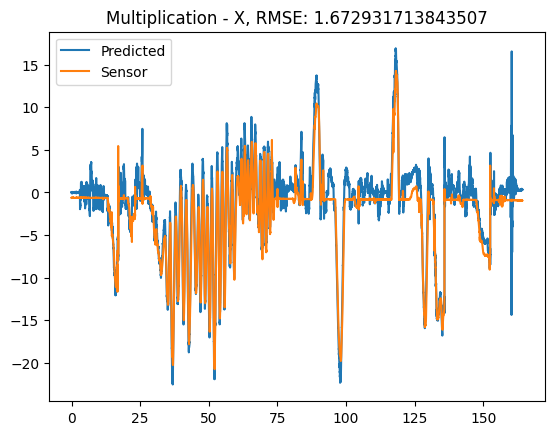

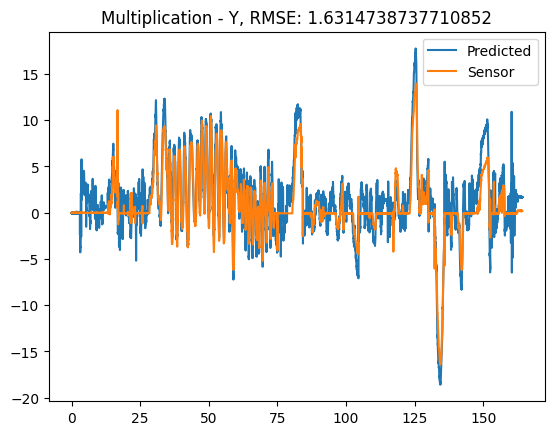

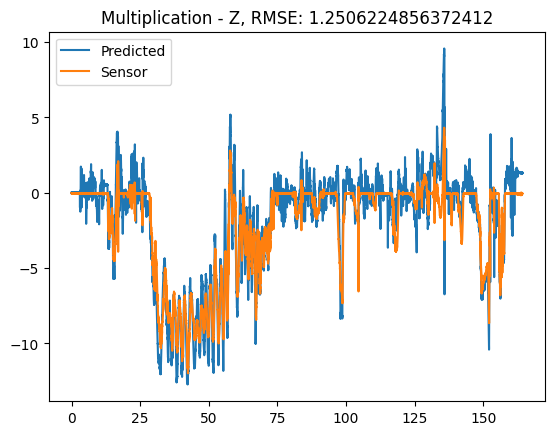

In [10]:
plt.plot(sensor_data_0['timestamps'],force_np[0:32852,0], label='Predicted')
plt.plot(sensor_data_0['timestamps'],sensor_data_0['x'], label='Sensor')
plt.legend()
plt.title('Multiplication - X, RMSE: '+str(RMSE(force_np[0:32852,0],sensor_data_0['x'])))
plt.savefig('Multiplication-X-cls.png')
plt.show()
plt.plot(sensor_data_0['timestamps'],force_np[0:32852,1], label='Predicted')
plt.plot(sensor_data_0['timestamps'],sensor_data_0['y'], label='Sensor')
plt.legend()
plt.title('Multiplication - Y, RMSE: '+str(RMSE(force_np[0:32852,1],sensor_data_0['y'])))
plt.savefig('Multiplication-Y-cls.png')
plt.show()
plt.plot(sensor_data_0['timestamps'],force_np[0:32852,2], label='Predicted')
plt.plot(sensor_data_0['timestamps'],sensor_data_0['z'], label='Sensor')
plt.legend()
plt.title('Multiplication - Z, RMSE: '+str(RMSE(force_np[0:32852,2],sensor_data_0['z'])))
plt.savefig('Multiplication-Z-cls.png')
plt.show()

Zero Velocity Baseline

In [11]:
base_table = lookup_table.loc[(abs(lookup_table['j1vel']) < 0.00003) & (abs(lookup_table['j2vel']) < 0.00003) & (abs(lookup_table['j3vel']) < 0.00003) & (abs(lookup_table['j4vel']) < 0.00003) & (abs(lookup_table['j5vel']) < 0.00003) & (abs(lookup_table['j6vel']) < 0.00003) ]

In [12]:
baselines={}
for i in range(6):
    baselines['base_'+str(i+1)]= np.mean(base_table['j'+str(i+1)+'eff'])

In [13]:
baselines

{'base_1': 0.0073470214187067095,
 'base_2': -0.1492200715940234,
 'base_3': -0.7959985063785147,
 'base_4': 0.0016097981683934023,
 'base_5': -0.0008074315561412184,
 'base_6': 0.020642912156498845}

In [14]:
efforts=[]



angle = -np.pi/4
Ra = torch.from_numpy(np.array([[np.cos(angle), -np.sin(angle), 0.0], [np.sin(angle), np.cos(angle), 0.0], [0.0, 0.0, 1.0]]).astype('float32'))



Rz = torch.from_numpy(np.matrix([[-1.0000, 0.0, 0.0], [0.0, -0.7071, -0.7071], [0.0, -0.7071, 0.7071]]).astype('float32'))
for i in range(1,7):
    efforts.append(force_sensor_0['j'+str(i)+'eff']-baselines['base_'+str(i)])
eff= np.transpose(efforts)
force = torch.zeros((eff.shape[0], 6))
eff_t = torch.from_numpy(eff.astype('float32'))
for i in range(eff.shape[0]):
    j = jacobian[i,:].reshape(6,6)
    jacobian_inv_t = torch.from_numpy(np.linalg.inv(j).transpose())
    force[i,:] = torch.matmul(jacobian_inv_t, eff_t[i,:])
    force[i,0:3] = torch.matmul(Ra, force[i,0:3])
force_np = force.numpy()

# Define the file path where you want to save the CSV file
file_path = "zero_v_cls.csv"

# Save the NumPy matrix as a CSV file
np.savetxt(file_path, force_np, delimiter=',', fmt='%.4f')

In [15]:
force_np

array([[-1.1026776 , -0.47937876, -1.2344381 , -0.14235392,  0.00626498,
         0.0440076 ],
       [-1.1195655 , -0.49683917, -1.2416936 , -0.14482415,  0.00414495,
         0.04378728],
       [-1.148226  , -0.49803382, -1.2617753 , -0.14711364,  0.00577079,
         0.04530136],
       ...,
       [-0.587306  ,  1.3306937 ,  0.2717017 ,  0.14121601,  0.1578767 ,
         0.0104395 ],
       [-0.58768046,  1.3046199 ,  0.27443588,  0.13952792,  0.15591002,
         0.01001249],
       [-0.62140846,  1.364711  ,  0.29767877,  0.14225419,  0.16491312,
         0.0124621 ]], dtype=float32)

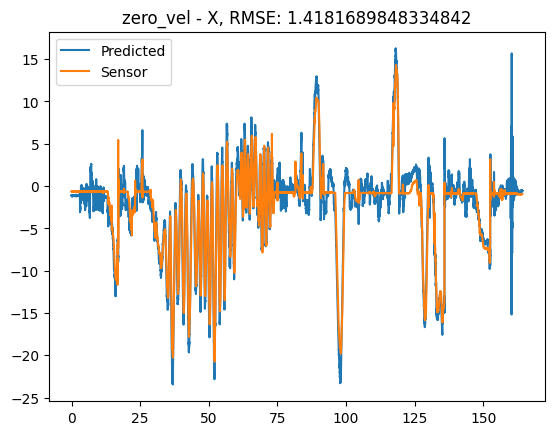

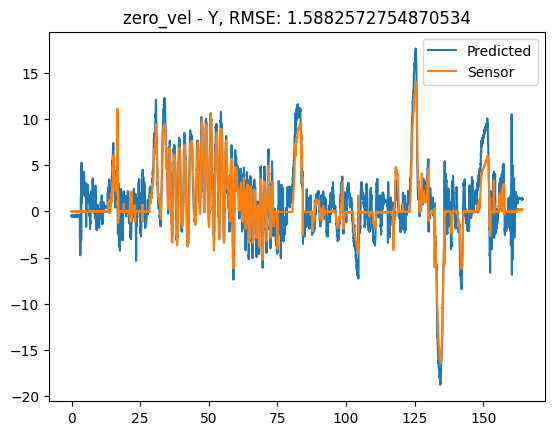

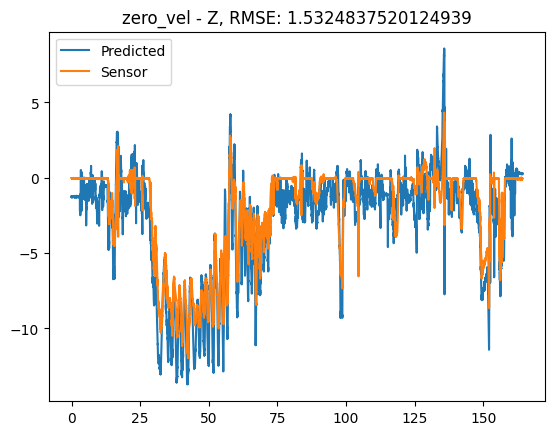

In [16]:
plt.plot(sensor_data_0['timestamps'],force_np[0:32852,0], label='Predicted')
plt.plot(sensor_data_0['timestamps'],sensor_data_0['x'], label='Sensor')
plt.legend()
plt.title('zero_vel - X, RMSE: '+str(RMSE(force_np[0:32852,0],sensor_data_0['x'])))
plt.savefig('zero_vel-X-cls.png')
plt.show()
plt.plot(sensor_data_0['timestamps'],force_np[0:32852,1], label='Predicted')
plt.plot(sensor_data_0['timestamps'],sensor_data_0['y'], label='Sensor')
plt.legend()
plt.title('zero_vel - Y, RMSE: '+str(RMSE(force_np[0:32852,1],sensor_data_0['y'])))
plt.savefig('zero_vel-Y-cls.png')
plt.show()
plt.plot(sensor_data_0['timestamps'],force_np[0:32852,2], label='Predicted')
plt.plot(sensor_data_0['timestamps'],sensor_data_0['z'], label='Sensor')
plt.legend()
plt.title('zero_vel - Z, RMSE: '+str(RMSE(force_np[0:32852,2],sensor_data_0['z'])))
plt.savefig('zero_vel-Z-cls.png')
plt.show()

Vector Search

In [17]:
lookup_table_np = lookup_table[lookup_table.columns[1:13]].to_numpy()
np.shape(lookup_table_np)

(243602, 12)

In [18]:
d = 12
nb = np.shape(lookup_table_np)[0]
nq = 1
import faiss                   # make faiss available
index = faiss.IndexFlatL2(d)   # build the index
print(index.is_trained)
index.add(lookup_table_np)                  # add vectors to the index
print(index.ntotal)

True
243602


In [19]:
force_sensor_0_np = force_sensor_0[force_sensor_0.columns[1:13]].to_numpy()
k = 1
D, I = index.search(np.array([force_sensor_0_np[0]]), k)  
print(I[0][0])

13255


In [20]:
efforts = []
base_arr = []
for i in range(len(force_sensor_0)):
    D, I = index.search(np.array([force_sensor_0_np[i]]), k)  
    base = lookup_table.loc[I[0][0]][lookup_table.columns[13:]]
    base_arr.append(base)
    efforts.append(force_sensor_0.loc[i][force_sensor_0.columns[13:]]-base)
efforts=np.array(efforts)
import torch
#jacobian = jacobian.numpy()
force = torch.zeros((efforts.shape[0], 6))
eff_t = torch.from_numpy(efforts.astype('float32'))
for i in range(efforts.shape[0]):
    j = jacobian[i,:].reshape(6,6)
    jacobian_inv_t = torch.from_numpy(np.linalg.inv(j).transpose())
    force[i,:] = torch.matmul(jacobian_inv_t, eff_t[i,:])
    force[i,0:3] = torch.matmul(Ra, force[i,0:3])
force_np = force.numpy()

# Define the file path where you want to save the CSV file
file_path = "force_np_cls.csv"
file_path_a = "sensor_data_0_cls.csv"

# Save the NumPy matrix as a CSV file
np.savetxt(file_path, force_np, delimiter=',', fmt='%.4f')
np.savetxt(file_path_a, sensor_data_0, delimiter=',', fmt='%.4f')

In [21]:
force_np

array([[ 0.37966642, -0.35745558, -0.87255   , -0.0365776 , -0.04590782,
        -0.0022288 ],
       [ 0.36278048, -0.3749179 , -0.8798131 , -0.03904818, -0.04802785,
        -0.00244993],
       [ 0.40257332, -0.45776042, -0.90795225, -0.0427362 , -0.05589846,
        -0.00506302],
       ...,
       [-0.44087225,  1.6664948 ,  0.75609386,  0.19434854,  0.20351079,
         0.0125142 ],
       [-0.4412499 ,  1.6404197 ,  0.75883055,  0.19266056,  0.2015441 ,
         0.01208767],
       [-0.4749776 ,  1.7005106 ,  0.78207344,  0.19538684,  0.2105472 ,
         0.01453729]], dtype=float32)

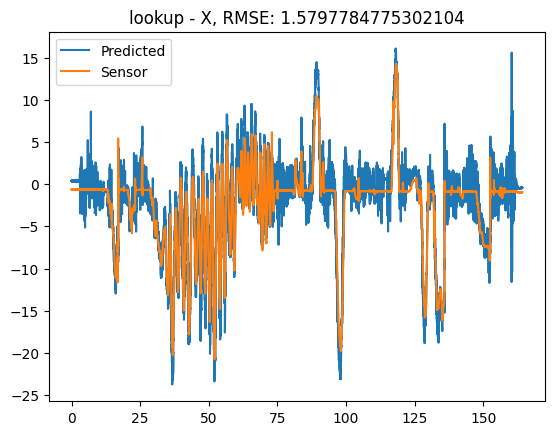

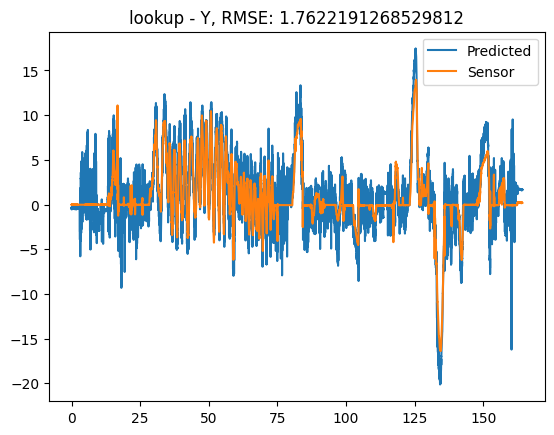

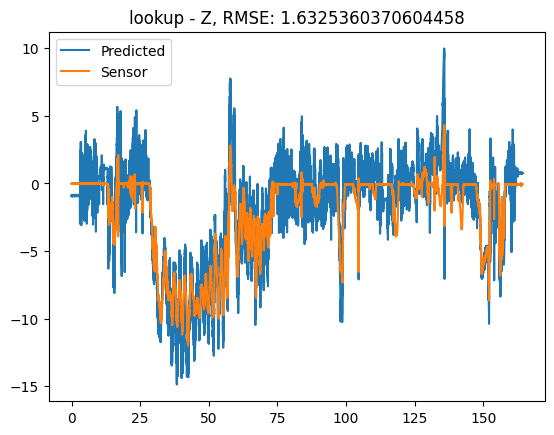

In [22]:
plt.plot(sensor_data_0['timestamps'],force_np[0:32852,0], label='Predicted')
plt.plot(sensor_data_0['timestamps'],sensor_data_0['x'], label='Sensor')
plt.legend()
plt.title('lookup - X, RMSE: '+str(RMSE(force_np[0:32852,0],sensor_data_0['x'])))
plt.savefig('lookup-X-cls.png')
plt.show()
plt.plot(sensor_data_0['timestamps'],force_np[0:32852,1], label='Predicted')
plt.plot(sensor_data_0['timestamps'],sensor_data_0['y'], label='Sensor')
plt.legend()
plt.title('lookup - Y, RMSE: '+str(RMSE(force_np[0:32852,1],sensor_data_0['y'])))
plt.savefig('lookup-Y-cls.png')
plt.show()
plt.plot(sensor_data_0['timestamps'],force_np[0:32852,2], label='Predicted')
plt.plot(sensor_data_0['timestamps'],sensor_data_0['z'], label='Sensor')
plt.legend()
plt.title('lookup - Z, RMSE: '+str(RMSE(force_np[0:32852,2],sensor_data_0['z'])))
plt.savefig('lookup-Z-cls.png')
plt.show()

Filtered Lookup Table

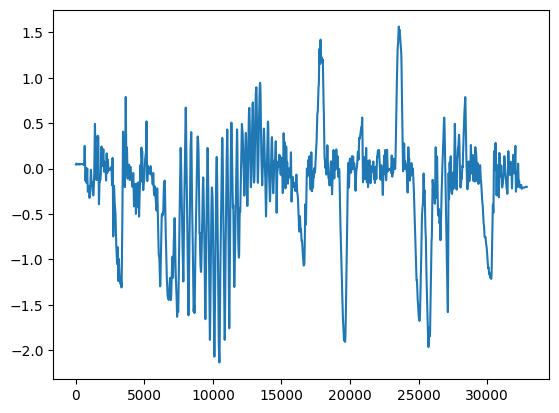

In [23]:
fs = 2000
fc = 30  # Cut-off frequency of the filter
w = fc / (fs / 2) # Normalize the frequency
b, a = signal.butter(5, w, 'low')
output = signal.filtfilt(b, a, efforts[:,0])
plt.plot(output)
plt.show()

In [24]:
efforts_f = np.zeros_like(efforts)
for i in range(6):
    efforts_f[:,i] = signal.filtfilt(b, a, efforts[:,i])

In [25]:
force = torch.zeros((efforts.shape[0], 6))
eff_t = torch.from_numpy(efforts_f.astype('float32'))
for i in range(efforts.shape[0]):
    j = jacobian[i,:].reshape(6,6)
    jacobian_inv_t = torch.from_numpy(np.linalg.inv(j).transpose())
    force[i,:] = torch.matmul(jacobian_inv_t, eff_t[i,:])
    force[i,0:3] = torch.matmul(Ra, force[i,0:3])
force_np = force.numpy()

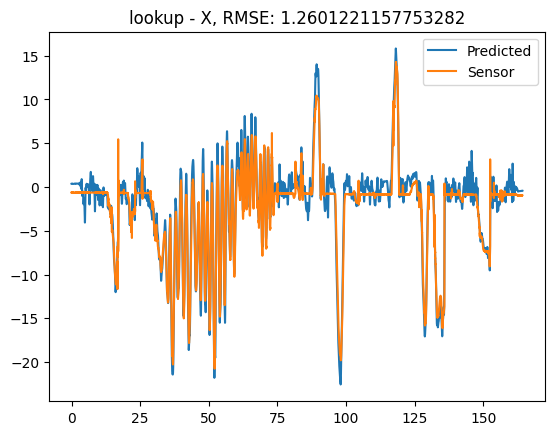

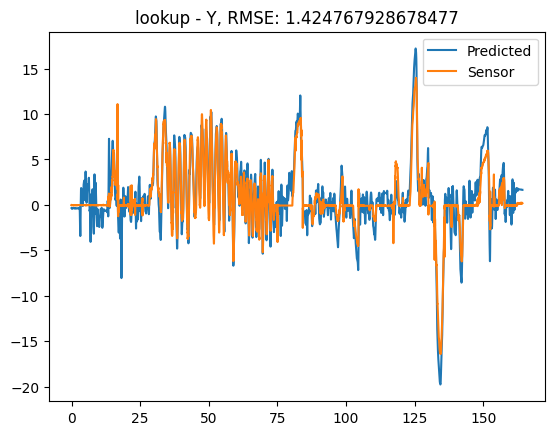

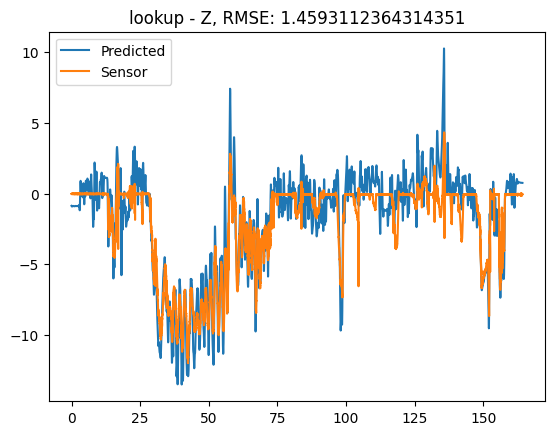

In [26]:
plt.plot(sensor_data_0['timestamps'],force_np[0:32852,0], label='Predicted')
plt.plot(sensor_data_0['timestamps'],sensor_data_0['x'], label='Sensor')
plt.legend()
plt.title('lookup - X, RMSE: '+str(RMSE(force_np[0:32852,0],sensor_data_0['x'])))
plt.savefig('lookup-X-cls.png')
plt.show()
plt.plot(sensor_data_0['timestamps'],force_np[0:32852,1], label='Predicted')
plt.plot(sensor_data_0['timestamps'],sensor_data_0['y'], label='Sensor')
plt.legend()
plt.title('lookup - Y, RMSE: '+str(RMSE(force_np[0:32852,1],sensor_data_0['y'])))
plt.savefig('lookup-Y-cls.png')
plt.show()
plt.plot(sensor_data_0['timestamps'],force_np[0:32852,2], label='Predicted')
plt.plot(sensor_data_0['timestamps'],sensor_data_0['z'], label='Sensor')
plt.legend()
plt.title('lookup - Z, RMSE: '+str(RMSE(force_np[0:32852,2],sensor_data_0['z'])))
plt.savefig('lookup-Z-cls.png')
plt.show()